<a href="https://colab.research.google.com/github/labonibiswas/SepsisDetectionTBC/blob/V1/TBC_with_orignal_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''3) Loading, Padding, Splitting, and Scaling the Original Imbalanced Dataset'''

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

print("Loading Original Imbalanced Dataset...")
# --- 1. LOAD THE RAW DATA ---
raw_df = pd.read_csv('original_dataset_with_selected_columns.csv')

feature_cols = ['HR','O2Sat','Temp','SBP','DBP','Resp','Age','Gender']
target_col = 'SepsisLabel'
WINDOW_SIZE = 5

print("Cleaning and Padding data to exactly 5 hours per patient...")

# --- 2. UNIVERSAL PADDING & CLEANING FUNCTION ---
def clean_and_pad(group):
    # Fill missing sensor data (Forward fill, then backward fill)
    group = group.ffill().bfill().fillna(0)

    current_len = len(group)
    if current_len >= WINDOW_SIZE:
        return group.tail(WINDOW_SIZE) # Truncate: Take last 5 hours
    else:
        # Pad: Repeat the first known hour to fill the gap
        num_missing = WINDOW_SIZE - current_len
        padding = pd.concat([group.iloc[[0]]] * num_missing, ignore_index=True)
        return pd.concat([padding, group], ignore_index=True)

# Apply the function and assign it to YOUR original variable name
final_dataset = raw_df.groupby('Patient_ID', group_keys=False).apply(clean_and_pad)

# --- 3. SPLIT BY PATIENT ID ---
unique_ids = final_dataset['Patient_ID'].unique()
train_ids, test_ids = train_test_split(unique_ids, test_size=0.3, random_state=42)

print(f"Total Patients: {len(unique_ids)}")
print(f"Training Patients: {len(train_ids)}")
print(f"Testing Patients:  {len(test_ids)}")

# Create the dataframes using the original variable names
train_df = final_dataset[final_dataset['Patient_ID'].isin(train_ids)].copy()
test_df = final_dataset[final_dataset['Patient_ID'].isin(test_ids)].copy()

# --- 4. SCALE THE DATA (StandardScaler) ---
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print("Data Scaled successfully.")

# --- 5. RESHAPE TO 3D ---
def create_3d_dataset(dataframe):
    X, y = [], []
    for pid, group in dataframe.groupby('Patient_ID'):
        X.append(group[feature_cols].values)
        y.append(group[target_col].max()) # 1 if Sepsis, 0 if Healthy
    return np.array(X), np.array(y)

print("Reshaping to 3D...")
X_train, y_train = create_3d_dataset(train_df)
X_test, y_test = create_3d_dataset(test_df)

print("\n" + "-" * 40)
print(f"✅ Training Data Shape: {X_train.shape}")
print(f"✅ Testing Data Shape:  {X_test.shape}")
print("-" * 40)

Loading Original Imbalanced Dataset...
Cleaning and Padding data to exactly 5 hours per patient...


/tmp/ipykernel_1202/4242197948.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_dataset = raw_df.groupby('Patient_ID', group_keys=False).apply(clean_and_pad)


Total Patients: 40336
Training Patients: 28235
Testing Patients:  12101
Data Scaled successfully.
Reshaping to 3D...

----------------------------------------
✅ Training Data Shape: (28235, 5, 8)
✅ Testing Data Shape:  (12101, 5, 8)
----------------------------------------


In [ ]:
'''4)TBC Layer'''

import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv1D, Concatenate

class TiedBlockConv1D(Layer):
    def __init__(self, filters, kernel_size, blocks=2, padding='causal', dilation_rate=1, activation='relu', **kwargs):
        super(TiedBlockConv1D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.blocks = blocks
        self.padding = padding
        self.dilation_rate = dilation_rate
        self.activation = activation

        # The "Shared" Filter (This is the magic that saves memory)
        self.shared_conv = Conv1D(
            filters=filters // blocks,
            kernel_size=kernel_size,
            padding=padding,
            dilation_rate=dilation_rate,
            activation=activation
        )

    def call(self, inputs):
        # 1. Split features into blocks
        block_inputs = tf.split(inputs, num_or_size_splits=self.blocks, axis=2)
        # 2. Apply the SAME filter to every block
        block_outputs = [self.shared_conv(b) for b in block_inputs]
        # 3. Recombine
        return Concatenate(axis=2)(block_outputs)

    def get_config(self):
        config = super(TiedBlockConv1D, self).get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "blocks": self.blocks,
            "padding": self.padding,
            "dilation_rate": self.dilation_rate,
            "activation": self.activation
        })
        return config

print("✅ TBC Layer Ready.")

✅ TBC Layer Ready.


In [ ]:
'''5)Building TBC Model'''

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalMaxPooling1D, Input
from tensorflow.keras.optimizers import Adam

FILTERS = 48
KERNEL = 3        # Kernel 3 captures slightly longer patterns than 2.
DROPOUT = 0.4     # High dropout prevents overfitting on synthetic SMOTE data.
BEST_LR = 1e-3         # Standard learning rate.

print("Building TBC Model...")

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])), # (5 hours, 8 features)

    # Layer 1: TBC (Captures immediate vitals changes)
    TiedBlockConv1D(
        filters=FILTERS,
        kernel_size=KERNEL,
        blocks=2,             # Split 8 features into 2 blocks of 4
        padding='causal',
        activation='relu',
        dilation_rate=1
    ),
    Dropout(DROPOUT),

    # Layer 2: TBC (Captures trends over the full 5 hours)
    TiedBlockConv1D(
        filters=FILTERS,  # Keep filters consistent
        kernel_size=KERNEL,
        blocks=2,
        padding='causal',
        activation='relu',
        dilation_rate=2       # Dilation lets us see history
    ),
    Dropout(DROPOUT),

    # Summarize & Output
    GlobalMaxPooling1D(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=BEST_LR),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])


model.summary()

Building TBC Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tied_block_conv1d               │ (None, 5, 48)          │           312 │
│ (TiedBlockConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 48)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tied_block_conv1d_1             │ (None, 5, 48)          │         1,752 │
│ (TiedBlockConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 48)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 48)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
'''6) TBC Model Training'''

from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

# --- 1. Calculate Class Weights ---
# This forces the model to pay extra attention to the minority class (Sepsis)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
# Convert to dictionary format for Keras
weight_dict = dict(enumerate(class_weights))

print(f" Calculated Class Weights: {weight_dict}")

# --- 2. Train with Weights ---
print("Starting Training...")
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=weight_dict,  # <--- THIS IS THE KEY CHANGE
    verbose=1
)


# --- 3. Smart Evaluation (Threshold Tuning) ---
print("\nCalculating Optimization Metrics...")
y_pred_prob = model.predict(X_test).ravel()

# Find the threshold that maximizes Sensitivity + Specificity
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]

print(f"🔎 Optimization Found: Best Decision Threshold = {best_thresh:.4f}")

# Apply the Optimized Threshold
y_pred = (y_pred_prob > best_thresh).astype(int)

# --- 4. The Scorecard ---
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + tn + fp + fn)
roc_auc = auc(fpr, tpr)

print("\n" + "-"*40)
print(f"✅ Accuracy:    {accuracy*100:.2f}%")
print(f"✅ AUC Score:   {roc_auc:.4f}")
print(f"✅ Sensitivity: {sensitivity*100:.2f}% (Recall)")
print(f"✅ Specificity: {specificity*100:.2f}%")
print("-" * 40)
print(f"Sepsis Patients Correctly Found: {tp}")
print(f"Sepsis Patients Missed:          {fn}")


 Calculated Class Weights: {0: np.float64(0.539886802554591), 1: np.float64(6.767737296260786)}
Starting Training...
Epoch 1/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7601 - auc: 0.7846 - loss: 0.5612 - val_accuracy: 0.7165 - val_auc: 0.7824 - val_loss: 0.6057
Epoch 2/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7470 - auc: 0.7822 - loss: 0.5625 - val_accuracy: 0.8096 - val_auc: 0.7811 - val_loss: 0.5379
Epoch 3/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7541 - auc: 0.7810 - loss: 0.5639 - val_accuracy: 0.7856 - val_auc: 0.7824 - val_loss: 0.5532
Epoch 4/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7585 - auc: 0.7819 - loss: 0.5634 - val_accuracy: 0.7689 - val_auc: 0.7812 - val_loss: 0.5641
Epoch 5/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7537 - auc: 0.7836 - loss: 0.5611 - val_accuracy: 0.7358 - val_auc: 0.7806 - val_loss: 0.5910
Epoch 6/60
442/442 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7494 - auc: 0.77

Predicting on Test Data...
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


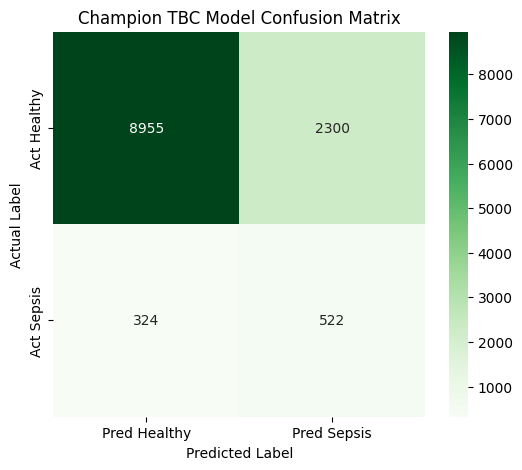


--- Detailed Report ---
              precision    recall  f1-score   support

     Healthy       0.97      0.80      0.87     11255
      Sepsis       0.18      0.62      0.28       846

    accuracy                           0.78     12101
   macro avg       0.58      0.71      0.58     12101
weighted avg       0.91      0.78      0.83     12101


SAFETY CHECK:
 Sepsis Patients Correctly Found: 522
 Sepsis Patients Missed:          324
 Recall (Sensitivity):            61.70%


In [ ]:
'''7) Confusion Matrix'''
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get Predictions from TBC Model
print("Predicting on Test Data...")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Visualise it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Healthy', 'Pred Sepsis'],
            yticklabels=['Act Healthy', 'Act Sepsis'])
plt.title(f'TBC Model Confusion Matrix') # Adjust title based on your previous output
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Print the numbers clearly
print("\n--- Detailed Report ---")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sepsis']))

# 5. Medical Safety Check
tn, fp, fn, tp = cm.ravel()
print(f"\nSAFETY CHECK:")
print(f" Sepsis Patients Correctly Found: {tp}")
print(f" Sepsis Patients Missed:          {fn}")
print(f" Recall (Sensitivity):            {tp / (tp + fn):.2%}")


In [ ]:
''' 8) K fold cross velidation'''
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# --- 1. PREPARE DATA FOR CV ---
# We merge the existing Train/Test split back together to get the full dataset
X_full = np.concatenate([X_train, X_test], axis=0)
y_full = np.concatenate([y_train, y_test], axis=0)

print(f"Starting 10-Fold Cross Validation on {len(X_full)} samples...")

# --- 2. CONFIGURATION ---
FOLDS = 10
EPOCHS = 40        # Slightly reduced epochs to save time (since we run it 10x)
BATCH_SIZE = 64
kfold = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

# Lists to store results
acc_scores = []
auc_scores = []
sens_scores = []
spec_scores = []

# --- 3. THE CROSS-VALIDATION LOOP ---
fold_no = 1
for train_index, val_index in kfold.split(X_full, y_full):
    print(f"\n🔄 Running Fold {fold_no} / {FOLDS}...")

    # A. Split Data for this Fold
    X_train_fold, X_val_fold = X_full[train_index], X_full[val_index]
    y_train_fold, y_val_fold = y_full[train_index], y_full[val_index]

    # B. Calculate Weights for this specific fold (Important for imbalance/35:65)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_fold),
        y=y_train_fold
    )
    weight_dict = dict(enumerate(class_weights))

    # C. Re-Build a FRESH Model (Clear previous memory)
    tf.keras.backend.clear_session()

    model_cv = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),

        # Layer 1
        TiedBlockConv1D(filters=48, kernel_size=3, blocks=2, padding='causal', activation='relu', dilation_rate=1),
        Dropout(0.4),

        # Layer 2
        TiedBlockConv1D(filters=48, kernel_size=3, blocks=2, padding='causal', activation='relu', dilation_rate=2),
        Dropout(0.4),

        GlobalMaxPooling1D(),
        Dense(1, activation='sigmoid')
    ])

    model_cv.compile(optimizer=Adam(learning_rate=1e-3),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

    # D. Train
    # We turn verbose=0 to keep the output clean (no progress bar spam)
    model_cv.fit(X_train_fold, y_train_fold,
                 epochs=EPOCHS,
                 batch_size=BATCH_SIZE,
                 class_weight=weight_dict,
                 verbose=0)

    # E. Evaluate
    y_pred_prob = model_cv.predict(X_val_fold, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Calculate Metrics
    acc = accuracy_score(y_val_fold, y_pred)
    auc = roc_auc_score(y_val_fold, y_pred_prob)

    tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    print(f"   > Accuracy: {acc*100:.2f}% | AUC: {auc:.4f} | Recall: {sensitivity*100:.2f}%")

    acc_scores.append(acc)
    auc_scores.append(auc)
    sens_scores.append(sensitivity)
    spec_scores.append(specificity)

    fold_no += 1

# --- 4. FINAL REPORT ---
print("\n" + "="*40)
print("🏆 10-FOLD CROSS VALIDATION RESULTS")
print("="*40)
print(f"✅ Average Accuracy:    {np.mean(acc_scores)*100:.2f}% (+/- {np.std(acc_scores)*100:.2f}%)")
print(f"✅ Average AUC Score:   {np.mean(auc_scores):.4f}")
print(f"✅ Average Sensitivity: {np.mean(sens_scores)*100:.2f}% (Recall)")
print(f"✅ Average Specificity: {np.mean(spec_scores)*100:.2f}%")
print("-" * 40)


Starting 10-Fold Cross Validation on 40336 samples...

🔄 Running Fold 1 / 10...
   > Accuracy: 78.24% | AUC: 0.7650 | Recall: 60.41%

🔄 Running Fold 2 / 10...
   > Accuracy: 76.85% | AUC: 0.7943 | Recall: 66.55%

🔄 Running Fold 3 / 10...
   > Accuracy: 80.12% | AUC: 0.8055 | Recall: 64.16%

🔄 Running Fold 4 / 10...
   > Accuracy: 84.56% | AUC: 0.7917 | Recall: 52.56%

🔄 Running Fold 5 / 10...
   > Accuracy: 77.07% | AUC: 0.7428 | Recall: 57.48%

🔄 Running Fold 6 / 10...
   > Accuracy: 77.37% | AUC: 0.7954 | Recall: 65.99%

🔄 Running Fold 7 / 10...
   > Accuracy: 79.79% | AUC: 0.7893 | Recall: 60.75%

🔄 Running Fold 8 / 10...
   > Accuracy: 76.79% | AUC: 0.7759 | Recall: 60.75%

🔄 Running Fold 9 / 10...
   > Accuracy: 81.63% | AUC: 0.7710 | Recall: 55.29%

🔄 Running Fold 10 / 10...
   > Accuracy: 79.87% | AUC: 0.7644 | Recall: 57.68%

🏆 10-FOLD CROSS VALIDATION RESULTS
✅ Average Accuracy:    79.23% (+/- 2.37%)
✅ Average AUC Score:   0.7795
✅ Average Sensitivity: 60.16% (Recall)
✅ Averag

Generating AUC-ROC Metrics...
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ Final AUC-ROC Score: 0.7851


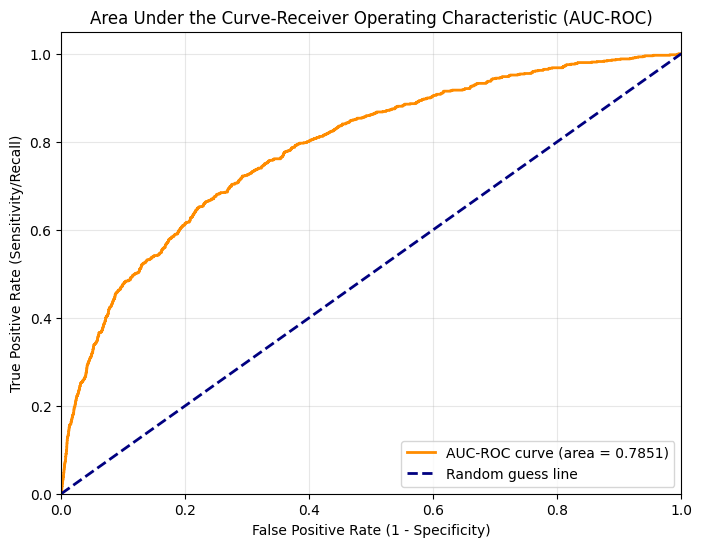

In [ ]:
# --- 4) EVALUATION: AUC-ROC CURVE ---
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("Generating AUC-ROC Metrics...")

# 1. Get predicted probabilities from the model
# We use .predict() on X_test (Shape: 11278, 5, 8)
y_pred_proba = model.predict(X_test).ravel()

# 2. Calculate FPR, TPR, and AUC
# y_test contains the true labels (0 for Healthy, 1 for Sepsis)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"✅ Final AUC-ROC Score: {roc_auc:.4f}")

# 3. Diagrammatic Representation (Plotting)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC-ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label=f'Random guess line') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Area Under the Curve-Receiver Operating Characteristic (AUC-ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Save the figure for your research report
plt.savefig('sepsis_roc_curve.png', dpi=300)
plt.show()